# Lire le dataset issu de l'étape cleaning

In [395]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger dataset
df = pd.read_csv('../data/processed/step2_cleaning.csv')

# Standardiser noms colonnes
df.columns = df.columns.str.lower()

print("Shape :", df.shape)
df.head()

Shape : (4372, 53)


,customerid,recency,frequency,monetarytotal,monetaryavg,monetarystd,monetarymin,monetarymax,totalquantity,avgquantitypertransaction,...,basketsizecategory,productdiversity,gender,accountstatus,country,churn,regyear,regmonth,regday,regweekday
0,17850,302,11,3589.26875,16.950737,13.603662,-30.60,107.25,1693.000,5.426282,...,Moyen,Explorateur,Unknown,Active,United Kingdom,1,2010,7,17,5
1,13047,32,11,3079.10000,15.709694,11.684769,-15.00,68.00,1355.000,6.913265,...,Moyen,Explorateur,M,Active,United Kingdom,0,2010,10,4,0
2,12583,3,11,3589.26875,28.634821,23.150132,-60.84,132.80,2176.125,19.956175,...,Grand,Explorateur,Unknown,Active,France,0,2009,9,12,5
3,13748,96,5,948.25000,33.866071,42.953119,9.36,204.00,439.000,15.678571,...,Grand,Explorateur,Unknown,Active,United Kingdom,1,2010,1,28,3
4,15100,330,6,635.10000,105.850000,215.986263,-131.40,350.40,58.000,9.666667,...,Moyen,Spécialisé,M,Active,United Kingdom,1,2009,12,10,3


1. Analyse rapide des colonnes

In [396]:
# Colonnes numériques
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Colonnes numériques :", num_cols)

# Colonnes catégorielles
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print("Colonnes catégorielles :", cat_cols)

Colonnes numériques : ['customerid', 'recency', 'frequency', 'monetarytotal', 'monetaryavg', 'monetarystd', 'monetarymin', 'monetarymax', 'totalquantity', 'avgquantitypertransaction', 'minquantity', 'maxquantity', 'customertenuredays', 'firstpurchasedaysago', 'preferreddayofweek', 'preferredhour', 'preferredmonth', 'weekendpurchaseratio', 'avgdaysbetweenpurchases', 'uniqueproducts', 'uniquedescriptions', 'avgproductspertransaction', 'uniquecountries', 'negativequantitycount', 'zeropricecount', 'cancelledtransactions', 'returnratio', 'totaltransactions', 'uniqueinvoices', 'avglinesperinvoice', 'age', 'supportticketscount', 'satisfactionscore', 'churn', 'regyear', 'regmonth', 'regday', 'regweekday']
Colonnes catégorielles : ['rfmsegment', 'agecategory', 'spendingcategory', 'customertype', 'favoriteseason', 'preferredtimeofday', 'region', 'loyaltylevel', 'churnriskcategory', 'weekendpreference', 'basketsizecategory', 'productdiversity', 'gender', 'accountstatus', 'country']


# 2. Création de nouvelles features numériques

# 1. Features basiques

1.1 Dépense par jour

In [397]:
df['monetaryperday'] = df['monetarytotal'] / (df['recency'] + 1)
#client dépense combien par jour => client dépense combien par jour

1.2 Panier moyen amélioré

In [398]:
df['avgbasketvalue'] = df['monetarytotal'] / (df['frequency'] + 1)
#taille moyenne du panier => client VIP vs petit client

1.3 Intensité d’achat

In [399]:
df['purchaseintensity'] = df['frequency'] / (df['customertenuredays'] + 1)
#fréquence d’achat dans le temps => client fidèle ou pas

1.4 Ratio récence / ancienneté

In [400]:
df['tenureratio'] = df['recency'] / (df['customertenuredays'] + 1)
#compare ancienneté vs activité récente => détecter churn 

# Visualisation des distributions

In [401]:
df[['monetarytotal', 'recency', 'monetaryperday',
    'frequency', 'avgbasketvalue',
    'purchaseintensity', 'tenureratio']].head(10)

,monetarytotal,recency,monetaryperday,frequency,avgbasketvalue,purchaseintensity,tenureratio
0,3589.26875,302,11.845771,11,299.105729,0.152778,4.194444
1,3079.10000,32,93.306061,11,256.591667,0.032070,0.093294
2,3589.26875,3,897.317188,11,299.105729,0.029650,0.008086
3,948.25000,96,9.775773,5,158.041667,0.017921,0.344086
4,635.10000,330,1.918731,6,90.728571,0.136364,7.500000
5,3589.26875,26,132.935880,11,299.105729,0.031519,0.074499
6,3589.26875,8,398.807639,11,299.105729,0.029973,0.021798
7,3589.26875,16,211.133456,11,299.105729,0.030726,0.044693
8,3589.26875,1,1794.634375,11,299.105729,0.029412,0.002674
9,3589.26875,3,897.317188,11,299.105729,0.029570,0.008065


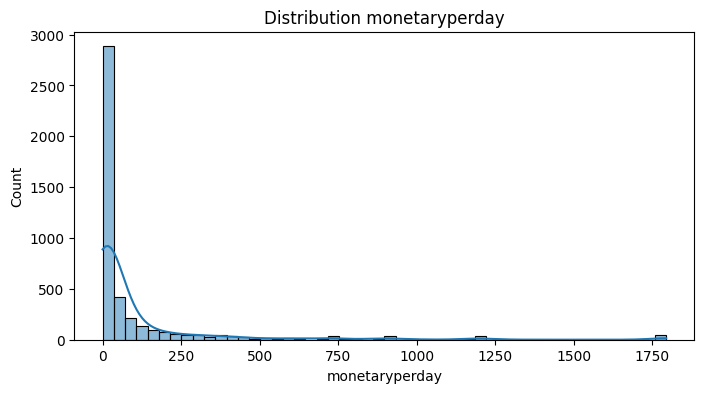

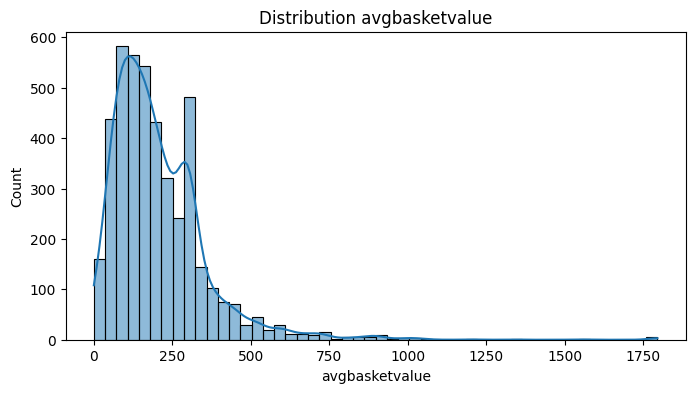

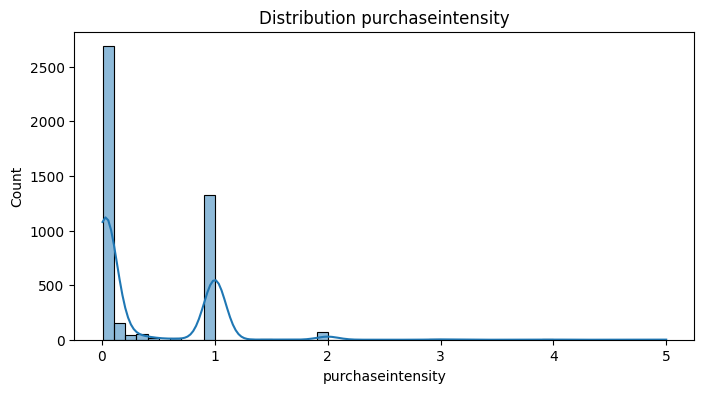

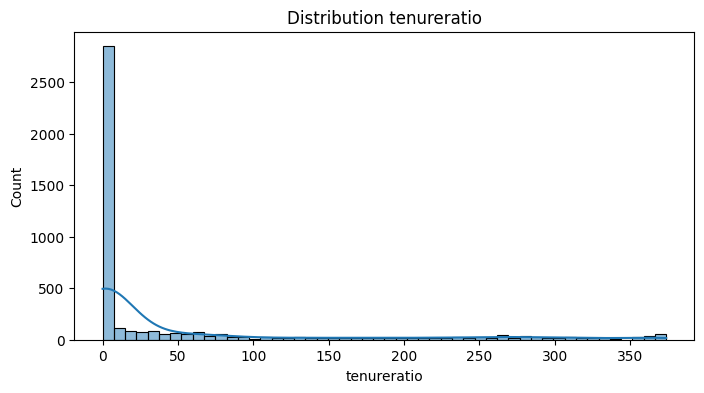

In [402]:
features_to_plot = ['monetaryperday','avgbasketvalue','purchaseintensity','tenureratio']

for col in features_to_plot:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution {col}")
    plt.show()

    #pour tenureratio #valeur élevée = client inactif ⚠️

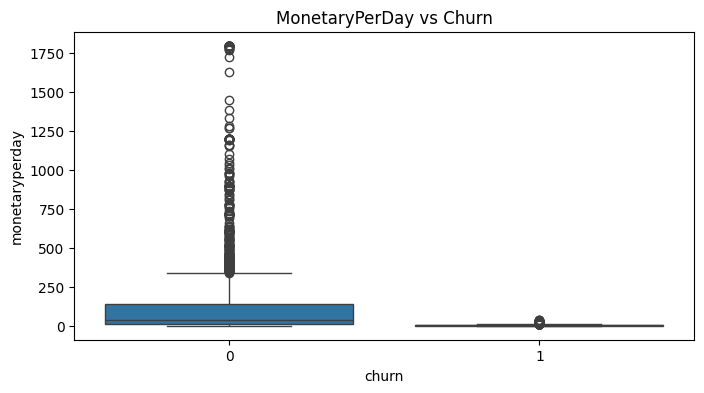

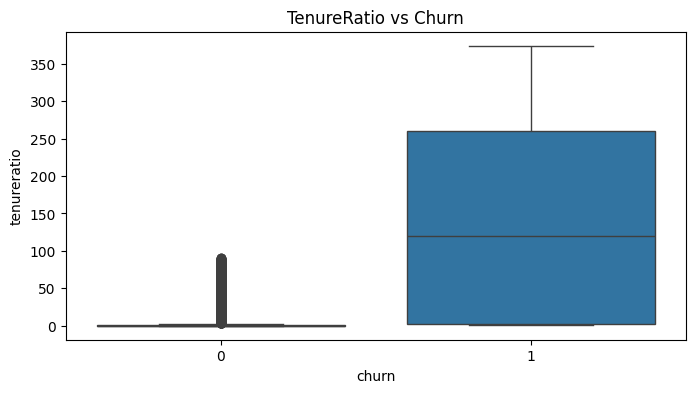

In [403]:
# Boxplots vs Churn
plt.figure(figsize=(8,4))
sns.boxplot(x='churn', y='monetaryperday', data=df)
plt.title("MonetaryPerDay vs Churn")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='churn', y='tenureratio', data=df)
plt.title("TenureRatio vs Churn")
plt.show()

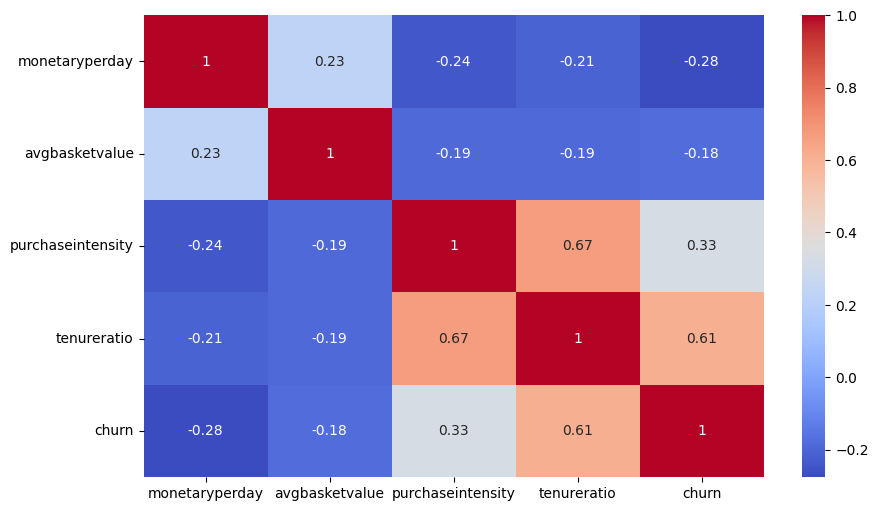

In [404]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['monetaryperday','avgbasketvalue',
                'purchaseintensity','tenureratio','churn']].corr(),
            annot=True, cmap='coolwarm')
plt.show()

# 2. Features comportementales

2.1 Diversité produits

In [405]:
df['productdiversityratio'] = df['uniqueproducts'] / (df['frequency'] + 1)
#diversité des produits achetés => client qui achète toujours les mêmes produits vs client qui varie

2.2 Impact des retours

In [406]:
df['returnimpact'] = df['returnratio'] * df['monetarytotal']
#impact des retours sur la valeur du client => client qui fait beaucoup de retours et dépense beaucoup = client à risque



2.3 Engagement client

In [407]:
df['engagementscore'] = (df['frequency']+df['totalquantity']+df['uniqueproducts']) 
#score d’engagement global => client très actif vs client peu actif
df['engagementscorenormalized'] = df['engagementscore'] / df['customertenuredays']
#normaliser par ancienneté pour éviter biais

2.4 Score client

In [408]:
df['customerscore'] = (df['frequency']*0.4 + df['monetarytotal']*0.4 + df['recency']*0.2)
#score global pondéré => client à fort potentiel vs client à faible potentiel
df['customerscorenormalized'] = df['customerscore'] / df['customertenuredays']
#normaliser par ancienneté pour éviter biais



In [409]:
df.head(10)


,customerid,recency,frequency,monetarytotal,monetaryavg,monetarystd,monetarymin,monetarymax,totalquantity,avgquantitypertransaction,...,monetaryperday,avgbasketvalue,purchaseintensity,tenureratio,productdiversityratio,returnimpact,engagementscore,engagementscorenormalized,customerscore,customerscorenormalized
0,17850,302,11,3589.26875,16.950737,13.603662,-30.60,107.25,1693.000,5.426282,...,11.845771,299.105729,0.152778,4.194444,2.000000,172.560998,1728.000,24.338028,1500.5075,21.133908
1,13047,32,11,3079.10000,15.709694,11.684769,-15.00,68.00,1355.000,6.913265,...,93.306061,256.591667,0.032070,0.093294,8.833333,377.032653,1472.000,4.304094,1242.4400,3.632865
2,12583,3,11,3589.26875,28.634821,23.150132,-60.84,132.80,2176.125,19.956175,...,897.317188,299.105729,0.029650,0.008086,9.583333,57.199502,2302.125,6.221959,1440.7075,3.893804
3,13748,96,5,948.25000,33.866071,42.953119,9.36,204.00,439.000,15.678571,...,9.775773,158.041667,0.017921,0.344086,4.000000,0.000000,468.000,1.683453,400.5000,1.440647
4,15100,330,6,635.10000,105.850000,215.986263,-131.40,350.40,58.000,9.666667,...,1.918731,90.728571,0.136364,7.500000,0.142857,317.550000,65.000,1.511628,322.4400,7.498605
5,15291,26,11,3589.26875,42.169817,49.090861,-35.49,243.36,2074.000,19.027523,...,132.935880,299.105729,0.031519,0.074499,5.250000,197.574427,2148.000,6.172414,1445.3075,4.153182
6,14688,8,11,3589.26875,14.226685,23.644470,-72.15,153.00,2176.125,8.974930,...,398.807639,299.105729,0.029973,0.021798,12.333333,319.934819,2335.125,6.380123,1441.7075,3.939092
7,17809,16,11,3589.26875,72.306562,142.206440,-717.23,425.00,2015.000,31.484375,...,211.133456,299.105729,0.030726,0.044693,3.916667,168.246973,2073.000,5.806723,1443.3075,4.042878
8,15311,1,11,3589.26875,23.853609,46.625077,-275.00,408.00,2176.125,15.142513,...,1794.634375,299.105729,0.029412,0.002674,47.583333,161.380209,2758.125,7.394437,1440.3075,3.861414
9,14527,3,11,3589.26875,7.627478,9.759291,-80.00,87.60,2049.000,2.026706,...,897.317188,299.105729,0.029570,0.008065,27.583333,138.458438,2391.000,6.444744,1440.7075,3.883309


# 3. Transformations log pour réduire la skewness

In [410]:
log_features = ['monetaryperday','avgbasketvalue','returnimpact']

for col in log_features:
    df[col + '_log'] = np.log1p(df[col])

# 4. Encodage cyclique et catégorisation

In [411]:
# Encodage cyclique des mois et jours
df['regmonth_sin'] = np.sin(2 * np.pi * df['regmonth']/12)
df['regmonth_cos'] = np.cos(2 * np.pi * df['regmonth']/12)
df['regweekday_sin'] = np.sin(2 * np.pi * df['regweekday']/7)
df['regweekday_cos'] = np.cos(2 * np.pi * df['regweekday']/7)
df.drop(columns=['regmonth','regweekday'], inplace=True)

cat_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True) 

# Catégorisation de la récence
# df['RecencyCategory'] = pd.cut(df['Recency'], bins=[0,30,90,180,365,np.inf],
                            #    labels=['Very Recent','Recent','Moderate','Old','Very Old'])
# One-Hot Encoding pour variables catégorielles
# df = pd.get_dummies(df, columns=['RecencyCategory'], drop_first=True)

# Colonnes catégorielles à encoder
# cat_cols = ['Gender','AccountStatus','Country']

# df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# # Vérification rapide
# print(df.head())



visualisation 
1. Visualiser l’encodage cyclique

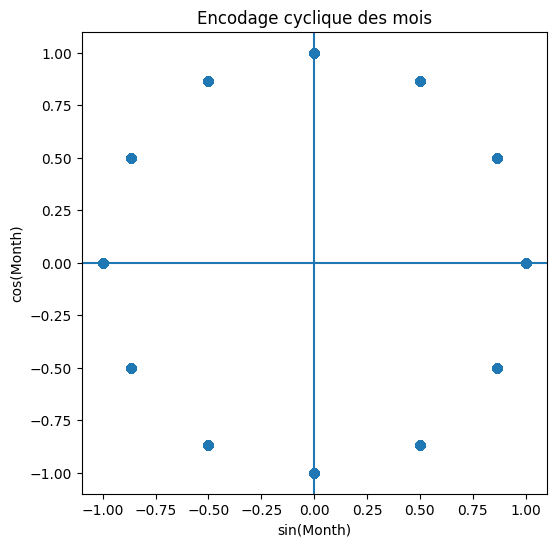

In [412]:
plt.figure(figsize=(6,6))

plt.scatter(df['regmonth_sin'], df['regmonth_cos'], alpha=0.5)

plt.xlabel("sin(Month)")
plt.ylabel("cos(Month)")
plt.title("Encodage cyclique des mois")

plt.axhline(0)
plt.axvline(0)

plt.show()



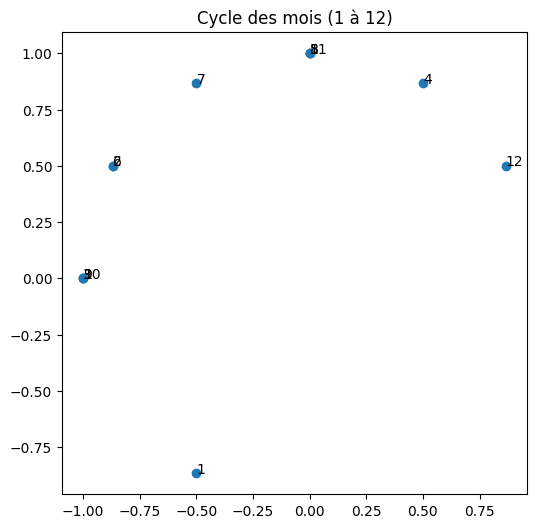

In [413]:
sample = df[['regmonth_sin','regmonth_cos']].head(12)

plt.figure(figsize=(6,6))
plt.scatter(sample['regmonth_sin'], sample['regmonth_cos'])

for i, txt in enumerate(range(1,13)):
    plt.annotate(txt, (sample.iloc[i,0], sample.iloc[i,1]))

plt.title("Cycle des mois (1 à 12)")
plt.show()

2. Visualiser RecencyCategory

2.1 Distribution des catégories

In [414]:
# df[['RecencyCategory_Recent',
#     'RecencyCategory_Moderate',
#     'RecencyCategory_Old',
#     'RecencyCategory_Very Old']].sum().plot(kind='bar')

# plt.title("Distribution des catégories de récence")
# plt.show()


In [415]:
df['customertenuredays'] = df['customertenuredays'].replace(0, 1)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print("NaN :", df.isnull().sum().sum())

NaN : 0


# 4. Normalisation des features numériques continues

In [416]:
# Sécuriser divisions
df['customertenuredays'] = df['customertenuredays'].replace(0, 1)

# Remplacer inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer NaN
df.fillna(df.median(numeric_only=True), inplace=True)

print("Colonnes disponibles :", df.columns)
print(df.columns.tolist())

# Normalisation
scaler = StandardScaler()

num_features = ['monetaryperday','avgbasketvalue','purchaseintensity','tenureratio',
                'productdiversityratio','returnimpact',
                'engagementscorenormalized','customerscorenormalized']

df[num_features] = scaler.fit_transform(df[num_features])

Colonnes disponibles : Index(['customerid', 'recency', 'frequency', 'monetarytotal', 'monetaryavg',
       'monetarystd', 'monetarymin', 'monetarymax', 'totalquantity',
       'avgquantitypertransaction',
       ...
       'country_RSA', 'country_Saudi Arabia', 'country_Singapore',
       'country_Spain', 'country_Sweden', 'country_Switzerland', 'country_USA',
       'country_United Arab Emirates', 'country_United Kingdom',
       'country_Unspecified'],
      dtype='object', length=140)
['customerid', 'recency', 'frequency', 'monetarytotal', 'monetaryavg', 'monetarystd', 'monetarymin', 'monetarymax', 'totalquantity', 'avgquantitypertransaction', 'minquantity', 'maxquantity', 'customertenuredays', 'firstpurchasedaysago', 'preferreddayofweek', 'preferredhour', 'preferredmonth', 'weekendpurchaseratio', 'avgdaysbetweenpurchases', 'uniqueproducts', 'uniquedescriptions', 'avgproductspertransaction', 'uniquecountries', 'negativequantitycount', 'zeropricecount', 'cancelledtransactions', 'retu

# 6. Vérification des nouvelles features

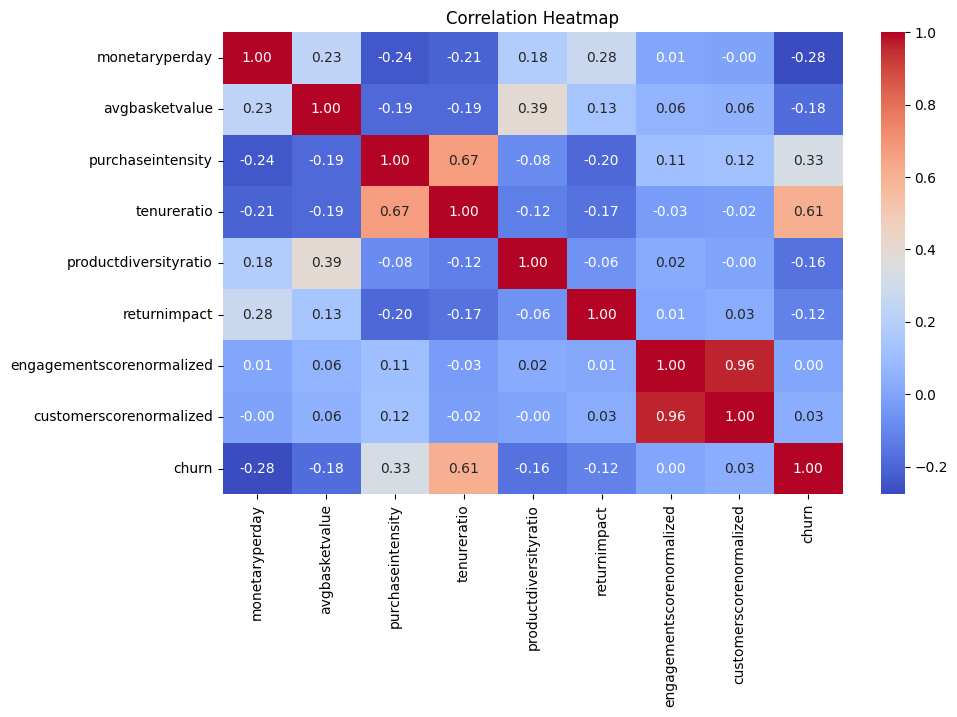

,customerid,recency,frequency,monetarytotal,monetaryavg,monetarystd,monetarymin,monetarymax,totalquantity,avgquantitypertransaction,...,engagementscorenormalized,customerscore,customerscorenormalized,monetaryperday_log,avgbasketvalue_log,returnimpact_log,regmonth_sin,regmonth_cos,regweekday_sin,regweekday_cos
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,...,4.372000e+03,4372.000000,4.372000e+03,4372.000000,4372.000000,4372.000000,4.372000e+03,4.372000e+03,4372.000000,4372.000000
mean,15299.677722,92.047118,3.916972,1120.895205,28.839013,88.672383,-86.425754,185.179522,664.773044,22.389288,...,-5.200679e-17,468.334294,2.600339e-17,2.913600,5.046964,1.349489,-3.984622e-02,7.330784e-02,-0.007874,0.004222
std,1722.390705,100.765435,3.286129,1115.470056,127.323926,2689.001161,2876.398935,2881.283699,682.460462,213.257466,...,1.000114e+00,439.392137,1.000114e+00,1.877699,0.913816,1.932325,7.088531e-01,7.005660e-01,0.710450,0.703854
min,12346.000000,1.000000,1.000000,0.000000,-4287.630000,0.000000,-168469.600000,-4287.630000,0.000000,-144.000000,...,-2.286498e-01,1.200000,-2.309837e-01,0.000000,0.000000,0.000000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969
25%,13812.750000,17.000000,1.000000,293.362500,10.985960,6.226414,-11.500000,31.800000,153.000000,5.475745,...,-1.390531e-01,144.573000,-1.416927e-01,1.329819,4.639110,0.000000,-8.660254e-01,-5.000000e-01,-0.781831,-0.900969
50%,15300.500000,50.000000,3.000000,648.075000,16.918616,10.349780,0.790000,52.020000,365.000000,9.494392,...,-9.833403e-02,279.750000,-1.052186e-01,2.651255,5.153326,0.000000,-2.449294e-16,6.123234e-17,0.000000,-0.222521
75%,16778.250000,143.000000,5.000000,1611.725000,23.542941,20.629858,6.960000,102.000000,962.250000,14.008333,...,-5.989132e-02,655.032000,-7.460909e-02,4.255606,5.661239,3.155542,5.000000e-01,8.660254e-01,0.781831,0.623490
max,18287.000000,374.000000,11.000000,3589.268750,3861.000000,137554.852393,3861.000000,168469.600000,2176.125000,12540.000000,...,5.701480e+01,1500.507500,5.488898e+01,7.493114,7.493114,7.849622,1.000000e+00,1.000000e+00,0.974928,1.000000


In [417]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_features + ['churn']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

df.describe()



In [418]:
# Vérifier qu'il n'y a plus de NaN
print("Valeurs manquantes :", df.isnull().sum().sum())

# Shape finale et aperçu
print("Shape finale :", df.shape)
df.head()


Valeurs manquantes : 0
Shape finale : (4372, 140)


,customerid,recency,frequency,monetarytotal,monetaryavg,monetarystd,monetarymin,monetarymax,totalquantity,avgquantitypertransaction,...,country_RSA,country_Saudi Arabia,country_Singapore,country_Spain,country_Sweden,country_Switzerland,country_USA,country_United Arab Emirates,country_United Kingdom,country_Unspecified
0,17850,302,11,3589.26875,16.950737,13.603662,-30.60,107.25,1693.000,5.426282,...,False,False,False,False,False,False,False,False,True,False
1,13047,32,11,3079.10000,15.709694,11.684769,-15.00,68.00,1355.000,6.913265,...,False,False,False,False,False,False,False,False,True,False
2,12583,3,11,3589.26875,28.634821,23.150132,-60.84,132.80,2176.125,19.956175,...,False,False,False,False,False,False,False,False,False,False
3,13748,96,5,948.25000,33.866071,42.953119,9.36,204.00,439.000,15.678571,...,False,False,False,False,False,False,False,False,True,False
4,15100,330,6,635.10000,105.850000,215.986263,-131.40,350.40,58.000,9.666667,...,False,False,False,False,False,False,False,False,True,False


In [419]:
print("Toutes les colonnes numériques ?", df.select_dtypes(include=['number']).columns)

Toutes les colonnes numériques ? Index(['customerid', 'recency', 'frequency', 'monetarytotal', 'monetaryavg',
       'monetarystd', 'monetarymin', 'monetarymax', 'totalquantity',
       'avgquantitypertransaction', 'minquantity', 'maxquantity',
       'customertenuredays', 'firstpurchasedaysago', 'preferreddayofweek',
       'preferredhour', 'preferredmonth', 'weekendpurchaseratio',
       'avgdaysbetweenpurchases', 'uniqueproducts', 'uniquedescriptions',
       'avgproductspertransaction', 'uniquecountries', 'negativequantitycount',
       'zeropricecount', 'cancelledtransactions', 'returnratio',
       'totaltransactions', 'uniqueinvoices', 'avglinesperinvoice', 'age',
       'supportticketscount', 'satisfactionscore', 'churn', 'regyear',
       'regday', 'monetaryperday', 'avgbasketvalue', 'purchaseintensity',
       'tenureratio', 'productdiversityratio', 'returnimpact',
       'engagementscore', 'engagementscorenormalized', 'customerscore',
       'customerscorenormalized', 'monet

# 7. Suppression des colonnes inutiles

In [420]:
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

protected_cols = ['customerscorenormalized']

to_drop = [
    col for col in upper.columns
    if col not in protected_cols and any(upper[col] > 0.9)
]

print("Colonnes supprimées :", to_drop)

df.drop(columns=to_drop, inplace=True)



Colonnes supprimées : ['monetarymin', 'monetarymax', 'totalquantity', 'minquantity', 'maxquantity', 'uniquedescriptions', 'cancelledtransactions', 'avglinesperinvoice', 'engagementscore', 'customerscore', 'weekendpreference_Weekend', 'country_Brazil', 'country_Japan', 'country_Lithuania', 'country_United Kingdom']


CLUSTERING

In [421]:
print("Colonnes dispo :", df.columns)
print(df.columns.tolist())


Colonnes dispo : Index(['customerid', 'recency', 'frequency', 'monetarytotal', 'monetaryavg',
       'monetarystd', 'avgquantitypertransaction', 'customertenuredays',
       'firstpurchasedaysago', 'preferreddayofweek',
       ...
       'country_Portugal', 'country_RSA', 'country_Saudi Arabia',
       'country_Singapore', 'country_Spain', 'country_Sweden',
       'country_Switzerland', 'country_USA', 'country_United Arab Emirates',
       'country_Unspecified'],
      dtype='object', length=125)
['customerid', 'recency', 'frequency', 'monetarytotal', 'monetaryavg', 'monetarystd', 'avgquantitypertransaction', 'customertenuredays', 'firstpurchasedaysago', 'preferreddayofweek', 'preferredhour', 'preferredmonth', 'weekendpurchaseratio', 'avgdaysbetweenpurchases', 'uniqueproducts', 'avgproductspertransaction', 'uniquecountries', 'negativequantitycount', 'zeropricecount', 'returnratio', 'totaltransactions', 'uniqueinvoices', 'age', 'supportticketscount', 'satisfactionscore', 'churn', 'regye

In [422]:
print(df.columns.tolist())

['customerid', 'recency', 'frequency', 'monetarytotal', 'monetaryavg', 'monetarystd', 'avgquantitypertransaction', 'customertenuredays', 'firstpurchasedaysago', 'preferreddayofweek', 'preferredhour', 'preferredmonth', 'weekendpurchaseratio', 'avgdaysbetweenpurchases', 'uniqueproducts', 'avgproductspertransaction', 'uniquecountries', 'negativequantitycount', 'zeropricecount', 'returnratio', 'totaltransactions', 'uniqueinvoices', 'age', 'supportticketscount', 'satisfactionscore', 'churn', 'regyear', 'regday', 'monetaryperday', 'avgbasketvalue', 'purchaseintensity', 'tenureratio', 'productdiversityratio', 'returnimpact', 'engagementscorenormalized', 'customerscorenormalized', 'monetaryperday_log', 'avgbasketvalue_log', 'returnimpact_log', 'regmonth_sin', 'regmonth_cos', 'regweekday_sin', 'regweekday_cos', 'rfmsegment_Dormants', 'rfmsegment_Fidèles', 'rfmsegment_Potentiels', 'agecategory_25-34', 'agecategory_35-44', 'agecategory_45-54', 'agecategory_55-64', 'agecategory_65+', 'agecategory_

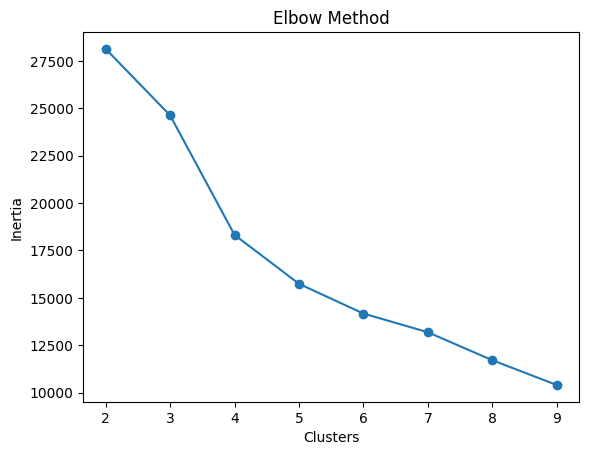

In [423]:
inertia = []
K_range = range(2, 10)
num_features = ['monetaryperday','avgbasketvalue','purchaseintensity','tenureratio',
                'productdiversityratio','returnimpact',
                'engagementscorenormalized','customerscorenormalized']

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[num_features])
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

PRÉPARATION RÉGRESSION

In [424]:
X_reg = df.drop(columns=['monetarytotal'])
y_reg = df['monetarytotal']

print("X_reg shape :", X_reg.shape)

X_reg shape : (4372, 124)


NETTOYAGE FINAL FEATURES

In [425]:
df.drop(columns=['customerid'], inplace=True, errors='ignore')
# df.drop(columns=['engagementscore'], inplace=True)
# Vérifier qu'il n'y a plus de NaN
print("Valeurs manquantes :", df.isnull().sum().sum())

# Shape finale et aperçu
print("Shape finale :", df.shape)
df.head()
print("Toutes les colonnes numériques ?", df.select_dtypes(include=['number']).columns)


df = df.drop(columns=['engagementscorenormalized'])

Valeurs manquantes : 0
Shape finale : (4372, 124)
Toutes les colonnes numériques ? Index(['recency', 'frequency', 'monetarytotal', 'monetaryavg', 'monetarystd',
       'avgquantitypertransaction', 'customertenuredays',
       'firstpurchasedaysago', 'preferreddayofweek', 'preferredhour',
       'preferredmonth', 'weekendpurchaseratio', 'avgdaysbetweenpurchases',
       'uniqueproducts', 'avgproductspertransaction', 'uniquecountries',
       'negativequantitycount', 'zeropricecount', 'returnratio',
       'totaltransactions', 'uniqueinvoices', 'age', 'supportticketscount',
       'satisfactionscore', 'churn', 'regyear', 'regday', 'monetaryperday',
       'avgbasketvalue', 'purchaseintensity', 'tenureratio',
       'productdiversityratio', 'returnimpact', 'engagementscorenormalized',
       'customerscorenormalized', 'monetaryperday_log', 'avgbasketvalue_log',
       'returnimpact_log', 'regmonth_sin', 'regmonth_cos', 'regweekday_sin',
       'regweekday_cos'],
      dtype='object')


# 8. Sauvegardage

In [426]:
df.to_csv('../data/processed/step3_feature_engineering.csv', index=False)

In [427]:
print("Toutes les colonnes numériques ?", df.select_dtypes(include=['object']).columns)


Toutes les colonnes numériques ? Index([], dtype='object')
